# Poker prediction — quick start

End-to-end demo of the `poker/` sub-project pipeline:

1. auto-download the [`RZ412/PokerBench`](https://huggingface.co/datasets/RZ412/PokerBench) preflop CSVs if they aren't already on disk
2. preprocess the raw CSVs into structured features
3. run the feature-engineering pipeline
4. train an XGBoost model with `PokerMLTrainer`
5. evaluate on the held-out test split
6. inspect feature importance and a single-hand prediction
7. persist the trained model

The notebook re-uses the same helpers wired into `scripts/run_pipeline.py`,
so it doubles as an integration test.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src' / 'data' / 'preprocess.py').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / 'src').is_dir(), f'could not locate poker/ project root from {os.getcwd()}'
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'project root : {PROJECT_ROOT}')
print(f'cwd          : {os.getcwd()}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)

project root : /workspace/poker
cwd          : /workspace/poker


In [2]:
from scripts.download_data import download_pokerbench

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'pokerbench'
TRAIN_CSV = RAW_DIR / 'train.csv'
TEST_CSV = RAW_DIR / 'test.csv'

if not (TRAIN_CSV.is_file() and TEST_CSV.is_file()):
    print('PokerBench CSVs not found on disk — downloading from Hugging Face Hub ...')
    ok = download_pokerbench(str(RAW_DIR))
    if not ok:
        raise RuntimeError('PokerBench download failed — see errors above')
else:
    print('PokerBench CSVs already present, skipping download')

print(f'  train CSV : {TRAIN_CSV}  ({TRAIN_CSV.stat().st_size / 1e6:.1f} MB)')
print(f'  test  CSV : {TEST_CSV}  ({TEST_CSV.stat().st_size / 1e6:.1f} MB)')

PokerBench CSVs already present, skipping download
  train CSV : /workspace/poker/data/raw/pokerbench/train.csv  (5.3 MB)
  test  CSV : /workspace/poker/data/raw/pokerbench/test.csv  (0.1 MB)


In [3]:
df_train = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)
print(f'raw train rows: {len(df_train)}')
print(f'raw test  rows: {len(df_test)}')
print(f'raw columns   : {list(df_train.columns)}')
df_train.head()

raw train rows: 63200
raw test  rows: 1000
raw columns   : ['prev_line', 'hero_pos', 'hero_holding', 'correct_decision', 'num_players', 'num_bets', 'available_moves', 'pot_size']


,prev_line,hero_pos,hero_holding,correct_decision,num_players,num_bets,available_moves,pot_size
0,HJ/2.0bb/CO/6.5bb/BTN/call/BB/allin,HJ,AhKc,fold,4,3,"['call', 'fold']",115.5
1,UTG/2.0bb/BTN/7.5bb/SB/20.0bb/BB/call/UTG/fold...,SB,AsAc,call,4,4,"['call', 'fold']",142.0
2,UTG/2.0bb/CO/call/BTN/9.5bb/BB/24.0bb/UTG/fold...,BTN,KhJh,fold,4,3,"['allin', 'call', 'fold']",38.0
3,CO/2.3bb/BTN/call/SB/12.5bb,BB,AsAh,27.0bb,4,2,"['allin', '27.0bb', 'call', 'fold']",18.1
4,UTG/2.0bb/CO/call/BTN/9.5bb/SB/23.0bb/BB/allin...,CO,JhJd,fold,5,4,['fold'],136.5


unique raw decision strings: 57 (many size-only variants like "3.0bb")
top 10:
correct_decision
fold      30000
call      25000
3.0bb       640
14.0bb      628
2.5bb       507
11.0bb      478
2.0bb       450
13.0bb      398
15.0bb      367
2.3bb       331
Name: count, dtype: int64


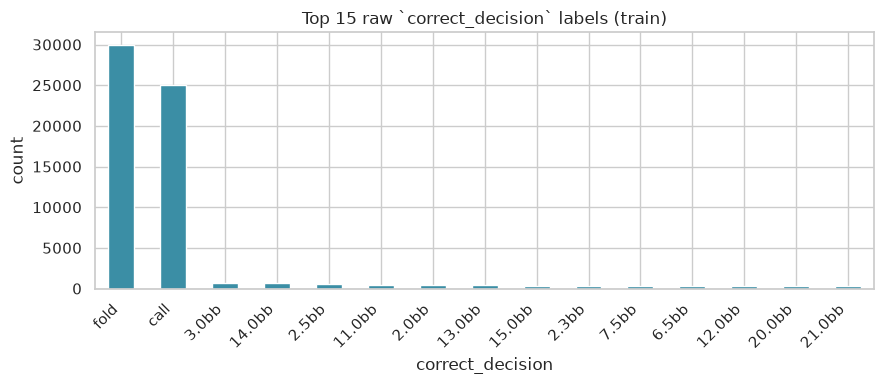

In [4]:
raw_decisions = df_train['correct_decision'].value_counts()
print(f'unique raw decision strings: {raw_decisions.size} (many size-only variants like "3.0bb")')
print('top 10:')
print(raw_decisions.head(10))

fig, ax = plt.subplots(figsize=(9, 4))
raw_decisions.head(15).plot(kind='bar', ax=ax, color='#3b8ea5')
ax.set_title('Top 15 raw `correct_decision` labels (train)')
ax.set_ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
from src.data.preprocess import PokerDataPreprocessor

preprocessor = PokerDataPreprocessor(raw_data_dir=str(RAW_DIR))

df_train_processed = preprocessor.extract_preflop_features(df_train)
df_test_processed = preprocessor.extract_preflop_features(df_test)

print(f'processed train shape: {df_train_processed.shape}')
print(f'processed test  shape: {df_test_processed.shape}')
print()
print('canonicalised decision distribution (train):')
print(df_train_processed['decision_type'].value_counts())

Extracting preflop features...


Extracted features shape: (63200, 22)
Extracting preflop features...
Extracted features shape: (1000, 22)
processed train shape: (63200, 22)
processed test  shape: (1000, 22)

canonicalised decision distribution (train):
decision_type
fold     30000
call     25000
raise     8000
check      200
Name: count, dtype: int64


In [6]:
from src.features.engineering import PokerFeatureEngineer

engineer = PokerFeatureEngineer()
df_train_feats = engineer.engineer_features(df_train_processed)
df_test_feats = engineer.engineer_features(df_test_processed)

print(f'engineered train shape: {df_train_feats.shape}')
print(f'engineered test  shape: {df_test_feats.shape}')

numeric_cols = df_train_feats.select_dtypes(include=[np.number]).columns
print(f'numeric feature columns: {len(numeric_cols)}')

missing = df_train_feats[numeric_cols].isna().sum()
if missing.sum() == 0:
    print('no missing values in numeric features')
else:
    print('columns with missing values:')
    print(missing[missing > 0])

Engineering poker features...
  - Hand strength features


  - Position features
  - Pot odds features


  - Action sequence features
Final feature shape: (63200, 58)
Engineering poker features...
  - Hand strength features
  - Position features
  - Pot odds features
  - Action sequence features
Final feature shape: (1000, 58)
engineered train shape: (63200, 58)
engineered test  shape: (1000, 58)
numeric feature columns: 45
no missing values in numeric features


In [7]:
from sklearn.model_selection import train_test_split

from src.models.train_ml import PokerMLTrainer

trainer = PokerMLTrainer(model_type='xgboost')
X, y = trainer.prepare_features(df_train_feats)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'train size: {len(X_train)}')
print(f'val   size: {len(X_val)}')

results = trainer.train(X_train, y_train, X_val, y_val)
print()
print('training summary:')
for k, v in results.items():
    print(f'  {k}: {v}')

Prepared 45 features
Target distribution:
decision_type
fold     30000
call     25000
raise     8000
check      200
Name: count, dtype: int64
train size: 50560
val   size: 12640

Training xgboost model...


Training accuracy: 0.9808
Validation accuracy: 0.9683

training summary:
  train_accuracy: 0.9808148734177216
  n_features: 45
  n_samples: 50560
  n_classes: 4
  classes: ['call', 'check', 'fold', 'raise']
  val_accuracy: 0.9682753164556962



Top 20 Most Important Features:
                feature  importance
8             num_allin    0.245751
18           is_premium    0.135884
41          allin_count    0.112201
12  hand_strength_score    0.072957
11           hand_group    0.044061
30             pot_size    0.041951
6               num_bet    0.032406
19          is_playable    0.026379
7             num_raise    0.026064
40          raise_count    0.020580
29      estimated_stack    0.019688
42    aggression_factor    0.016708
1              num_bets    0.015222
14       low_card_value    0.012055
4              num_fold    0.012044
43     last_action_type    0.011667
38           fold_count    0.011373
0           num_players    0.010673
3           num_actions    0.010544
2     hero_position_idx    0.010058


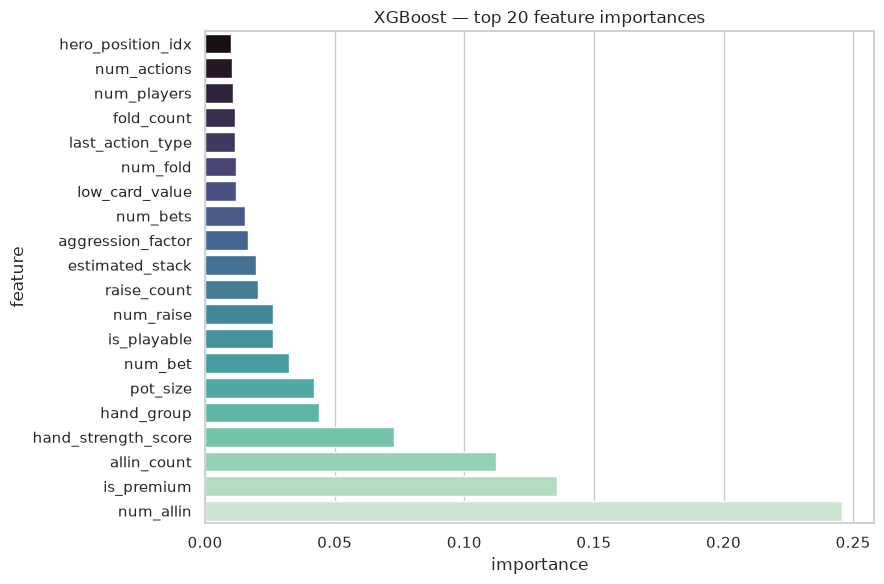

In [8]:
importance_df = trainer.get_feature_importance(top_n=20)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    x='importance',
    y='feature',
    data=importance_df.sort_values('importance'),
    ax=ax,
    palette='mako',
)
ax.set_title('XGBoost — top 20 feature importances')
plt.tight_layout()
plt.show()

In [9]:
X_test_prep, y_test_prep = trainer.prepare_features(df_test_feats)
test_results = trainer.evaluate(X_test_prep, y_test_prep)
print()
print(f'test accuracy: {test_results["accuracy"]:.4f}')

Prepared 45 features
Target distribution:
decision_type
call     250
raise    250
fold     250
check    250
Name: count, dtype: int64

Evaluating model...

Test Accuracy: 0.9840

Classification Report:
              precision    recall  f1-score   support

        call       0.96      0.99      0.98       250
       check       1.00      0.98      0.99       250
        fold       0.99      0.96      0.98       250
       raise       0.98      1.00      0.99       250

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


test accuracy: 0.9840


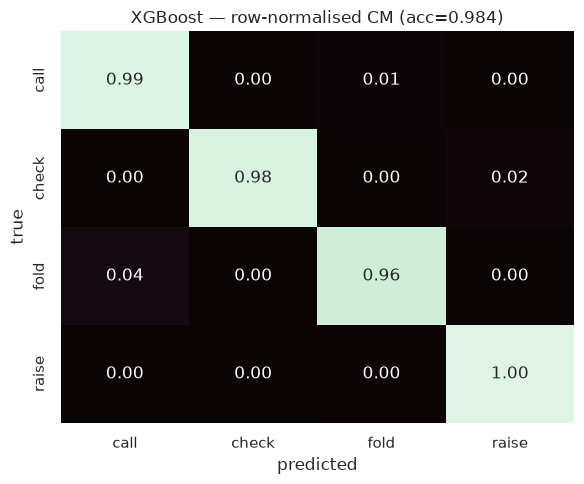

In [10]:
from sklearn.metrics import confusion_matrix

y_test_encoded = trainer.label_encoder.transform(y_test_prep)
y_pred_encoded = trainer.model.predict(X_test_prep)
cm = confusion_matrix(
    y_test_encoded, y_pred_encoded,
    labels=list(range(len(trainer.label_encoder.classes_))),
    normalize='true',
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='mako', cbar=False,
    xticklabels=trainer.label_encoder.classes_,
    yticklabels=trainer.label_encoder.classes_,
    ax=ax,
)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title(f'XGBoost — row-normalised CM (acc={test_results["accuracy"]:.3f})')
plt.tight_layout()
plt.show()

In [11]:
sample_idx = 0
sample_features = X_test_prep.iloc[sample_idx:sample_idx + 1]
sample_row = df_test_feats.iloc[sample_idx]

pred_encoded = trainer.model.predict(sample_features)
pred = trainer.label_encoder.inverse_transform(pred_encoded)[0]
pred_proba = trainer.model.predict_proba(sample_features)[0]

print(f'spot          : {sample_row["hero_pos"]:>4} holding {sample_row["hero_holding"]!s}   pot={sample_row["pot_size"]:.1f}bb')
print(f'prev_line     : {sample_row["prev_line"]}')
print(f'true action   : {y_test_prep.iloc[sample_idx]}')
print(f'predicted     : {pred}')
print()
print('probabilities :')
for label, prob in zip(trainer.label_encoder.classes_, pred_proba):
    marker = '<= true' if label == y_test_prep.iloc[sample_idx] else ''
    print(f'  {label:<8} {prob:.4f}   {marker}')

spot          :   SB holding KdKc   pot=117.0bb
prev_line     : UTG/2.0bb/BTN/call/SB/13.0bb/BB/allin/UTG/fold/BTN/fold
true action   : call
predicted     : call

probabilities :
  call     0.9948   <= true
  check    0.0000   
  fold     0.0051   
  raise    0.0000   


In [12]:
MODELS_DIR = PROJECT_ROOT / 'data' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / 'xgboost_quickstart.pkl'
trainer.save_model(str(model_path))
print(f'saved to: {model_path}')


Model saved to /workspace/poker/data/models/xgboost_quickstart.pkl
saved to: /workspace/poker/data/models/xgboost_quickstart.pkl


## Next steps

1. Try the other classical trainers (`--model-type lightgbm`, `--model-type random_forest`).
2. Train the PyTorch MLP baseline: `python src/models/train_nn.py --model-type mlp --epochs 20`.
3. Compare all algorithms side-by-side in `02_prediction_success_evaluation.ipynb`.
4. Fine-tune the LLM track (see the top-level README `LLM fine-tune track` section).